In [ ]:
# to=============================
# IMPORT LIBRARIES
# =============================from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.functions import *
from pyspark.sql.types import StringType
from datetime import datetime
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

In [ ]:
# =============================
# CREATE SPARK SESSION
# =============================
spark = SparkSession.builder.appName("capstone").getOrCreate()


In [ ]:
# =============================
# LOAD DATA
# =============================
def load_data(data):
    t1 = time.time()
    df = spark.read.options(header=True, inferSchema=True).csv(data)
    t2 = time.time()
    print("Duration:", np.round((t2 - t1), 2), "seconds")
    return df

In [ ]:
df1 = load_data("OnlineRetail.csv")

Duration: 10.6 seconds


In [ ]:
def datashape(data):
    print("Data shape (rows, columns):", data.count(), "x", len(data.columns))
datashape(df1)
df1.limit(5).show()


Data shape (rows, columns): 338924 x 8
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+



In [ ]:
# =============================
# SUMMARY STATISTICS
# =============================
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

In [ ]:
summary = df1.describe().toPandas()
summary = summary.T
summary.columns = summary.iloc[0]
summary = summary.drop(summary.index[0])
summary

summary,count,mean,stddev,min,max
InvoiceNo,338924,551350.7414458266,8910.468583118041,536365,C566565
StockCode,338924,28309.544804657213,17912.83921470967,10002,m
Description,337739,None,None,4 PURPLE FLOCK DINNER CANDLES,wrongly sold sets
Quantity,338924,9.688956816277395,189.21330235927735,-74215,74215
InvoiceDate,338924,None,None,1/10/2011 10:04,9/9/2011 9:52
UnitPrice,338924,4.830822019093664,110.35167490083863,-11062.06,38970.0
CustomerID,246729,15278.049309161064,1726.5182876353688,12346,18287
Country,338924,None,None,Australia,Unspecified


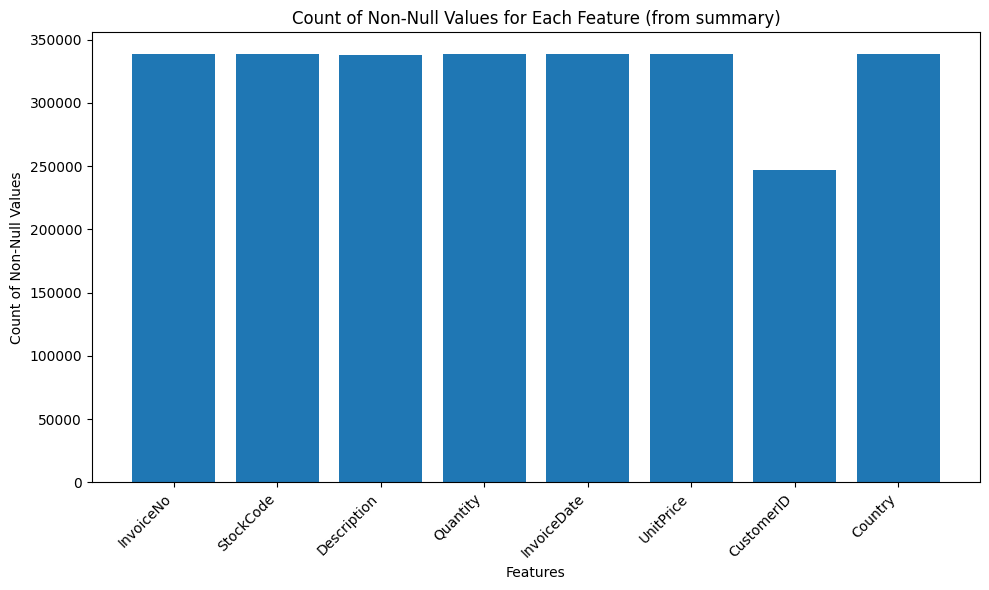

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a copy to avoid modifying the original summary DataFrame
summary_to_plot = summary.copy()

# Convert 'count' column to numeric, coercing errors to NaN
summary_to_plot['count'] = pd.to_numeric(summary_to_plot['count'], errors='coerce')

# Drop rows where 'count' is NaN after conversion (these were likely non-numeric original values)
summary_to_plot = summary_to_plot.dropna(subset=['count'])

# Plotting the count for each feature
plt.figure(figsize=(10, 6))
plt.bar(summary_to_plot.index, summary_to_plot['count'])
plt.xlabel("Features")
plt.ylabel("Count of Non-Null Values")
plt.title("Count of Non-Null Values for Each Feature (from summary)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# =============================
# MISSING VALUES CHECK
# =============================

# Dynamically create missing value conditions based on column type
missing_conditions = []
for c, dtype in df1.dtypes:
    # Start with a check for null values for all columns
    condition = col(c).isNull()

    # Add isnan() check only for numeric types
    if dtype.startswith("double") or dtype.startswith("float") or dtype.startswith("int") or dtype.startswith("long"):
        condition = condition | isnan(c)

    missing_conditions.append(count(when(condition, c)).alias(c))

# Select the counts of missing values based on the constructed conditions
missing = df1.select(missing_conditions)
missing.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1185|       0|          0|        0|     92195|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [ ]:
# =============================
# DATA CLEANING
# =============================

# Fix Country name
df1 = df1.replace(['EIRE'], ['Ireland'])

In [ ]:
# Convert Quantity to float
df1 = df1.withColumn("Quantity", col("Quantity").cast("Float"))

In [ ]:
# =============================
# CREATE AMOUNT COLUMN
# =============================
df1 = df1.withColumn("Amount", col("Quantity") * col("UnitPrice"))
df1.limit(5).show()

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|            Amount|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|   536365|   85123A|WHITE HANGING HEA...|     6.0|12/1/2010 8:26|     2.55|     17850|United Kingdom|15.299999999999999|
|   536365|    71053| WHITE METAL LANTERN|     6.0|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84406B|CREAM CUPID HEART...|     8.0|12/1/2010 8:26|     2.75|     17850|United Kingdom|              22.0|
|   536365|   84029G|KNITTED UNION FLA...|     6.0|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|     6.0|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
+---------+---------+---

In [ ]:
# =============================
# TOP 10 COUNTRIES BY TRANSACTIONS
# =============================
df1.groupBy("Country").count().sort(col("count").desc()).limit(10).show()

+--------------+------+
|       Country| count|
+--------------+------+
|United Kingdom|309195|
|       Germany|  6248|
|        France|  5145|
|       Ireland|  5092|
|   Netherlands|  1656|
|         Spain|  1644|
|       Belgium|  1333|
|   Switzerland|  1193|
|     Australia|  1013|
|      Portugal|   775|
+--------------+------+



In [ ]:
# =============================
# FILTER IRELAND DATA
# =============================
df1.filter(df1.Country == "Ireland").limit(5).show()

+---------+---------+--------------------+--------+---------------+---------+----------+-------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|    InvoiceDate|UnitPrice|CustomerID|Country|            Amount|
+---------+---------+--------------------+--------+---------------+---------+----------+-------+------------------+
|   536540|    22968|ROSE COTTAGE KEEP...|     4.0|12/1/2010 14:05|     9.95|     14911|Ireland|              39.8|
|   536540|   85071A|BLUE CHARLIE+LOLA...|     6.0|12/1/2010 14:05|     2.95|     14911|Ireland|17.700000000000003|
|   536540|   85071C|"CHARLIE+LOLA""EX...|     6.0|12/1/2010 14:05|     2.55|     14911|Ireland|15.299999999999999|
|   536540|    22355|CHARLOTTE BAG SUK...|    50.0|12/1/2010 14:05|     0.85|     14911|Ireland|              42.5|
|   536540|    21579|LOLITA  DESIGN  C...|     6.0|12/1/2010 14:05|     2.25|     14911|Ireland|              13.5|
+---------+---------+--------------------+--------+---------------+-----

In [ ]:
# =============================
# FILTER LARGE QUANTITY SALES
# =============================
df1.filter(df1.Quantity > 50000).show()

+---------+---------+--------------------+--------+---------------+---------+----------+--------------+-------+
|InvoiceNo|StockCode|         Description|Quantity|    InvoiceDate|UnitPrice|CustomerID|       Country| Amount|
+---------+---------+--------------------+--------+---------------+---------+----------+--------------+-------+
|   541431|    23166|MEDIUM CERAMIC TO...| 74215.0|1/18/2011 10:01|     1.04|     12346|United Kingdom|77183.6|
+---------+---------+--------------------+--------+---------------+---------+----------+--------------+-------+



In [ ]:
# =============================
# DAILY TRANSACTION COUNT
# =============================
daily_txn = df1.groupBy("InvoiceDate").count().sort("InvoiceDate", ascending=True)
daily_txn.show(10)

+---------------+-----+
|    InvoiceDate|count|
+---------------+-----+
|1/10/2011 10:04|    1|
|1/10/2011 10:07|    1|
|1/10/2011 10:08|    1|
|1/10/2011 10:32|   23|
|1/10/2011 10:35|   17|
|1/10/2011 10:36|    1|
|1/10/2011 10:44|    1|
|1/10/2011 10:58|   46|
|1/10/2011 11:09|   19|
|1/10/2011 11:22|   42|
+---------------+-----+
only showing top 10 rows


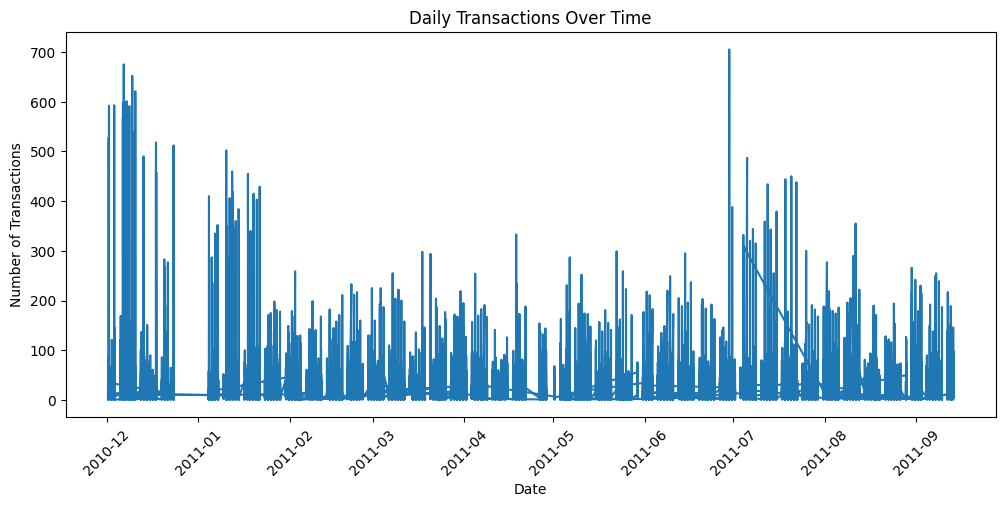

In [ ]:
# =============================
# FINAL RESULT CHART
# =============================

# Convert to pandas
daily_pd = daily_txn.toPandas()

# Convert date column (if needed)
daily_pd["InvoiceDate"] = pd.to_datetime(daily_pd["InvoiceDate"])

# Plot chart
plt.figure(figsize=(12, 5))
plt.plot(daily_pd["InvoiceDate"], daily_pd["count"])
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Daily Transactions Over Time")
plt.xticks(rotation=45)
plt.show()

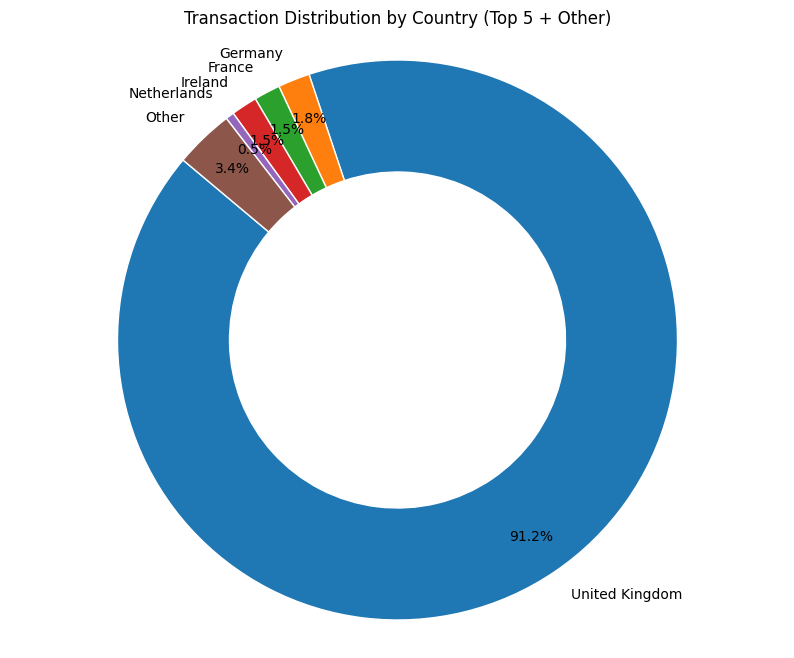

In [ ]:
# =============================
# PIE CHART FOR TOP COUNTRIES
# =============================

# Group by Country and count transactions
country_counts = df1.groupBy("Country").count()

# Sort and get top 5 countries
top_5_countries = country_counts.sort(col("count").desc()).limit(5).toPandas()

# Calculate count for 'Other' countries
other_count = country_counts.filter(~col("Country").isin(top_5_countries["Country"].tolist()))\
                               .agg(F.sum("count").alias("count")).collect()[0]["count"]

# Add 'Other' category to the DataFrame
if other_count is None: # Handle case where there are less than 5 countries
    other_count = 0
other_df = pd.DataFrame([{"Country": "Other", "count": other_count}])
final_country_data = pd.concat([top_5_countries, other_df])

# Plotting the pie chart with improved spacing
plt.figure(figsize=(10, 8))
plt.pie(final_country_data['count'],
        labels=final_country_data['Country'],
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85, # Distance of percentage labels from the center
        wedgeprops=dict(width=0.4, edgecolor='w')) # Adds space between slices and a white edge
plt.title("Transaction Distribution by Country (Top 5 + Other)")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# =============================
# MONTHLY TRANSACTION COUNT
# =============================
# Extract YearMonth from InvoiceDate for monthly aggregation
df_monthly = df1.withColumn("InvoiceMonth", date_format(to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm"), "yyyy-MM"))

monthly_txn = df_monthly.groupBy("InvoiceMonth").count().sort("InvoiceMonth", ascending=True)
monthly_txn.show(10)

+------------+-----+
|InvoiceMonth|count|
+------------+-----+
|     2010-12|42481|
|     2011-01|35147|
|     2011-02|27707|
|     2011-03|36748|
|     2011-04|29916|
|     2011-05|37030|
|     2011-06|36874|
|     2011-07|39518|
|     2011-08|35284|
|     2011-09|18219|
+------------+-----+



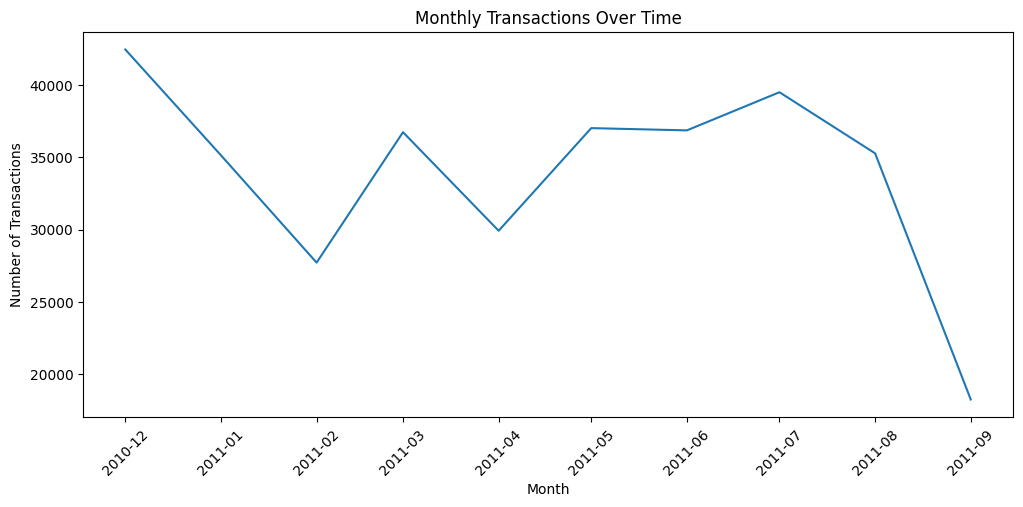

In [ ]:
# =============================
# MONTHLY TRANSACTION CHART
# =============================

# Convert to pandas
monthly_pd = monthly_txn.toPandas()

# Convert date column
monthly_pd["InvoiceMonth"] = pd.to_datetime(monthly_pd["InvoiceMonth"])

# Plot chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_pd["InvoiceMonth"], monthly_pd["count"])
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.title("Monthly Transactions Over Time")
plt.xticks(rotation=45)
plt.show()